Laboratorio 2 - Deep Learning. Modelos LSTM para las series de tiempo del Laboratorio 1 (ingreso de viajeros internacionales a Guatemala). Se reutilizan train.csv y test.csv generados en el Laboratorio 1 (split cronológico 70/30 por mes, corte en 2021-04) y dos de las series construidas en ese laboratorio: Total y Aérea.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.edgecolor'] = '#c3c2b7'
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.axis'] = 'y'
plt.rcParams['grid.color'] = '#e1e0d9'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['figure.figsize'] = (10, 4)

COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']

## 1. Series reutilizadas del Laboratorio 1

Mismo train.csv/test.csv y misma construcción de series por fecha y por Vía que en 02_modelo_arima.ipynb del Laboratorio 1, para que el split temporal sea idéntico al usado con ARIMA/Prophet/Holt-Winters.

In [2]:
train = pd.read_csv('train.csv', encoding='utf-8-sig')
test  = pd.read_csv('test.csv',  encoding='utf-8-sig')

for d in (train, test):
    d['fecha'] = pd.to_datetime(d['Año'].astype(str) + '-' + d['Mes cod'].astype(str) + '-01')

def build(df):
    total = df.groupby('fecha')['Viajero'].sum().sort_index().asfreq('MS')
    total.name = 'Total'
    via = df.groupby(['fecha', 'Vía'])['Viajero'].sum().unstack(fill_value=0).sort_index().asfreq('MS')
    return total, via

tot_tr, via_tr = build(train)
tot_te, via_te = build(test)

series_train = {'Total': tot_tr, 'Aérea': via_tr['Aérea']}
series_test  = {'Total': tot_te, 'Aérea': via_te['Aérea']}

for nombre in series_train:
    s_tr, s_te = series_train[nombre], series_test[nombre]
    print(f"{nombre:6s} -> train: {s_tr.index.min().date()} a {s_tr.index.max().date()} (n={len(s_tr)})"
          f" | test: {s_te.index.min().date()} a {s_te.index.max().date()} (n={len(s_te)})")

Total  -> train: 2009-01-01 a 2021-03-01 (n=147) | test: 2021-04-01 a 2026-06-01 (n=63)
Aérea  -> train: 2009-01-01 a 2021-03-01 (n=147) | test: 2021-04-01 a 2026-06-01 (n=63)


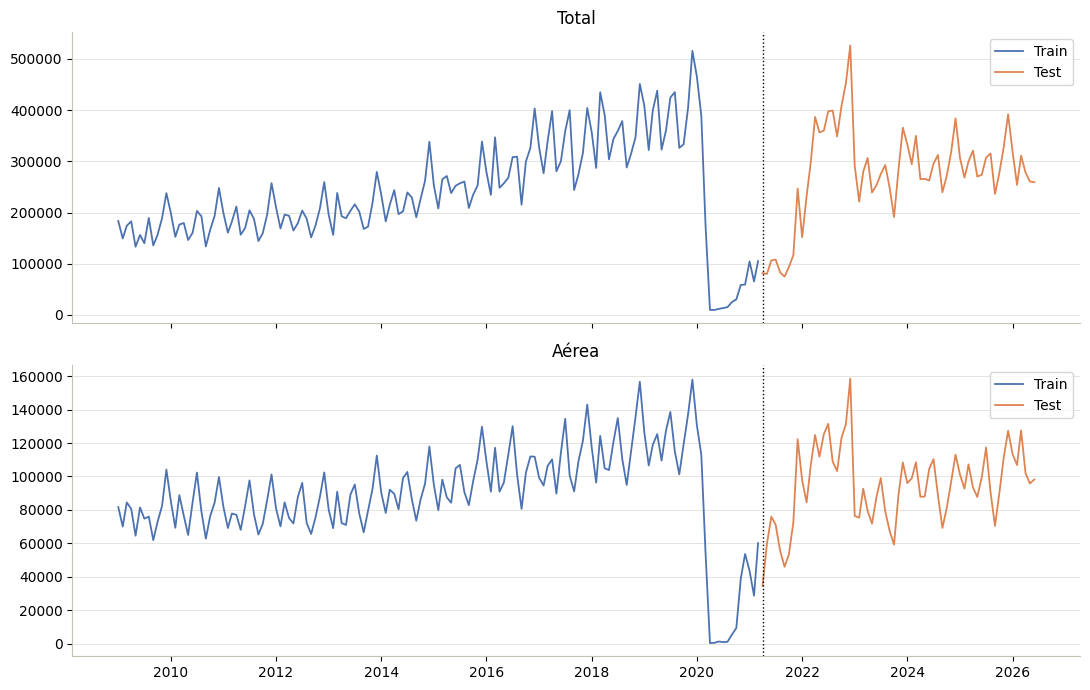

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, nombre in zip(axes, series_train):
    s_tr, s_te = series_train[nombre], series_test[nombre]
    ax.plot(s_tr.index, s_tr.values, color=COLORS[0], linewidth=1.3, label='Train')
    ax.plot(s_te.index, s_te.values, color=COLORS[1], linewidth=1.3, label='Test')
    ax.axvline(s_te.index.min(), color='black', linestyle=':', linewidth=1)
    ax.set_title(nombre)
    ax.legend()
fig.tight_layout()

In [4]:
# chequeo rápido: los valores deben coincidir con los de 02_modelo_arima.ipynb del Laboratorio 1
print('Total  train primeros 3 meses:', series_train['Total'].head(3).round(1).tolist())
print('Aérea  train primeros 3 meses:', series_train['Aérea'].head(3).round(1).tolist())
print('Total  test  últimos 3 meses:', series_test['Total'].tail(3).round(1).tolist())
print('Aérea  test  últimos 3 meses:', series_test['Aérea'].tail(3).round(1).tolist())

Total  train primeros 3 meses: [183505.6, 149426.3, 174237.2]
Aérea  train primeros 3 meses: [81693.0, 70099.0, 84494.0]
Total  test  últimos 3 meses: [278199.0, 260666.0, 259391.0]
Aérea  test  últimos 3 meses: [102029.0, 95804.0, 98211.0]


Las dos series (Total y Aérea) quedan con el mismo train/test del Laboratorio 1: 147 meses de entrenamiento (2009-01 a 2021-03) y 63 meses de prueba (2021-04 en adelante). Con esto ya se puede pasar a construir y tunear los modelos LSTM sobre series_train/series_test.